<a href="https://colab.research.google.com/github/hsultova/Softuni-AI-Agents-Workflows/blob/main/exam/exam_multi_agent_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Set up


*   OPENAI_API_KEY must be set as a Colab secret
*   Data file (recipes.md) should be uploaded if not found at /content/



# TODO: Project description

In [1]:
!pip install -q langchain langchain-openai langchain_text_splitters langchain_chroma

In [70]:
import json
import operator

from typing import TypedDict, Literal, Annotated
from pathlib import Path
from pydantic import BaseModel, Field, SecretStr
from IPython.display import Image

from google.colab import userdata, files

from langchain_openai import ChatOpenAI
from langchain_chroma import Chroma
from langchain_core.documents import Document
from langchain_text_splitters import MarkdownHeaderTextSplitter
from langchain.messages import HumanMessage, SystemMessage
from langchain_core.messages import BaseMessage, AIMessage
from langchain_core.prompts import PromptTemplate
from langchain_core.tools import create_retriever_tool
from langchain.tools import ToolRuntime, tool
from langchain.agents import create_agent, AgentState

from langgraph.graph import START, END, StateGraph
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore


In [3]:
OPENAI_MODEL = "gpt-4.1-mini"
openai_api_key = SecretStr(userdata.get("OPENAI_API_KEY"))

In [4]:
class Recipe(BaseModel):
  name: str
  country: str
  description: str
  ingredients: str
  preparation: str
  fact: str

In [5]:
RECIPES_PATH = '/content/recipes.md'

if not Path(RECIPES_PATH).exists():
  uploaded = files.upload()
  path_to_pdf = Path(next(iter(uploaded)))

with open(RECIPES_PATH) as file:
    text = file.read()
documents = [Document(page_content=text, metadata={"source": RECIPES_PATH})]

In [6]:
headers_to_split_on = [
  ("##", "name"),
  ("###", "section"),
]
for document in documents:
  splitter = MarkdownHeaderTextSplitter(headers_to_split_on=headers_to_split_on)
  chunks = splitter.split_text(document.page_content)

  recipes = {}

  for chunk in chunks:
    name = chunk.metadata.get("name", "").strip()
    section = chunk.metadata.get("section")
    content = chunk.page_content.strip()

    if name not in recipes:
      recipes[name] = {"name": name, "country": "", "ingredients": "", "preparation": "", "fact": ""}

    if section is None:
      # This is the intro chunk: first line is the country, rest is description
      lines = content.split("\n")
      recipes[name]["country"] = lines[0].strip("* ").strip()
    elif section == "INGREDIENTS":
      recipes[name]["ingredients"] = content
    elif section == "PREPARATION":
      recipes[name]["preparation"] = content
    elif section == "GOOD TO KNOW":
      recipes[name]["fact"] = content


In [7]:
documents_to_store = []

for recipe in recipes.values():
  page_content = (
    f"{recipe['name']}\n"
    f"{recipe['country']}\n\n"
    f"Ingredients:\n{recipe['ingredients']}\n\n"
    f"Preparation:\n{recipe['preparation']}\n\n"
    f"Fact:\n{recipe['fact']}"
  )

  document = Document(
    page_content=page_content,
    metadata={
      "name": recipe["name"],
      "country": recipe["country"],
      "ingredients": recipe["ingredients"],
      "preparation": recipe["preparation"],
      "fact": recipe["fact"],
    },
  )
  documents_to_store.append(document)

In [8]:
recipes_chromadb = Chroma(collection_name="recipes_db", persist_directory="/content/chroma")

In [9]:
recipes_chromadb.add_documents(documents_to_store)

['833eca4c-eb66-48d7-9bad-981f183544ef',
 '15fba227-9320-44f2-8aa3-d759ecc2beba',
 '228a6007-95b7-4b73-b0d1-34aa5daba5de',
 'c44fd943-bc7e-495f-b06f-cdb62e8956b0',
 '5869db85-be96-4887-8c37-3509e65c3844',
 '566d22c3-30c8-4e85-af9b-f0ea7ddb781d',
 '0d9d5598-df2a-4ee5-97ca-b1f45d81cb38',
 '3617e193-569c-4bfd-b8e8-6c7b894078f9',
 '1bc434f6-90ae-4010-9bde-28bd003589d9',
 '2b0fee84-463d-4cbf-8487-2054b97b945d',
 '96d5a139-022d-4dbe-bee2-f889bf0fdb70',
 '0fd43279-89fc-4b1b-b557-848802e640be',
 '4e01cdb6-77a2-44b6-91cb-302b5a899890',
 '412d0364-9dfc-4525-a0c4-301c5a1a2860',
 '4240bc85-be4b-45a2-8d84-1495fb4350f1',
 '225660bd-d4f4-462b-9c30-536837d694d5',
 '7d3fba9a-901a-4e43-88be-8ac17d33e009',
 '50b66dcb-2e8d-416f-8670-13e50391870f',
 '7808e7c2-30b1-4efc-883f-90ce74e129ef',
 '8cce7896-69a8-4051-8884-a495ea238e94',
 '75fd62aa-cd7a-4fe0-a2bc-9f888ed9114e',
 '190dd399-76be-4f56-a376-9bfcbdc518af',
 'ef4ff8cb-e65c-4065-bbce-2ec793aab982',
 '85c0755c-bd81-4723-905e-08bd370965ce',
 '172cf127-5110-

In [10]:
recipes_retriever = recipes_chromadb.as_retriever()

In [11]:
recipes_retriever_tool = create_retriever_tool(
    recipes_retriever,
    name="recipes_knowledge_retriever",
    description="""Retrieve relevant recipes from given constraints
      - a dish by name — 'Baklava', 'Carbonara', 'Guacamole', 'sushi'
      - a course or meal type — 'a dessert', 'a salad', 'a soup', 'a starter', 'breakfast', 'a light dinner'
      - a quality, mood or style — 'something comforting', 'spicy', 'sour',
      'quick', 'grilled'""")


In [80]:
class DietaryPreferences(BaseModel):
  diet_type: Literal["vegetarian","vegan","pescatarian", "mediterranean", "keto", "gluten-free", "no sugar", "other"]
  allergies: list[str] = Field(default_factory=list)
  allergies_confirmed: bool = Field(
    default=False,
    description=(
      "True only if the user was explicitly asked about allergies "
      "(this session or a prior one) and confirmed an answer, "
      "including 'none'. False means 'unknown', not 'no allergies'."
    ),
  ),
  dislikes: list[str] = Field(default_factory=list)
  servings: int = 4
  days: int = 7
  calorie_target: int | None = None
  budget: float | None = None
  cuisine_preferences: list[str] = Field(default_factory=list)

class RecipePlannerState(TypedDict):
  user_id: str
  user_request: str
  dietary_preferences: DietaryPreferences
  validation: str
  meal_plan_draft: dict | None
  meal_plan: dict | None
  messages: Annotated[list[BaseMessage], operator.add]
  shopping_list: dict| None

In [87]:
preferences_parser_model = ChatOpenAI(model=OPENAI_MODEL, api_key=openai_api_key).with_structured_output(DietaryPreferences)
preferences_parser_prompt = """You are extracting structured dietary preferences from a user's message for a
weekly meal-planning system. Output only the fields defined in the schema.

Rules:
- diet_type: infer from explicit statements only. Don't assume "healthy eating"
  implies vegetarian, etc.
- allergies: extract explicitly stated allergies/intolerances only. Do NOT infer
  additional allergies from dietary preferences (e.g. "vegan" does not imply a
  dairy allergy — it's a preference, not a safety constraint).
- If the user does not mention allergies at all, set allergies_confirmed=False
  and leave allergies=[]. Do not assume "no allergies mentioned" means
  "no allergies." This will trigger a clarifying question — that's intended.
- servings: if unstated, default to 4 and note the assumption in your reasoning.
- calorie_target / budget: leave null if not mentioned — do not estimate one.
- Normalize allergy/dislike terms to common ingredient names (e.g. "I can't do
  nuts" → "tree nuts"; "shellfish gives me hives" → "shellfish").

If the user references prior preferences you're given below, reconcile any
conflicts by favoring what they said in this message.
"""

meal_planner_model = ChatOpenAI(model=OPENAI_MODEL, api_key=openai_api_key)
meal_planner_prompt = f"""You are a meal planner assistent. Produce a JSON-structured 7-day(or preffered days by the user) plan given dietary preferences.
You need to use the `{recipes_retriever_tool.name}` for candidate recipes, and assembles a balanced weekly plan (variety, nutrition balance, no repeats, respects prep-time constraints) Your only job is creating meal plans, do not suggest to do something else, for example shoppiing lists, give preparation steps or something else."""

shopping_list_model = ChatOpenAI(model=OPENAI_MODEL, api_key=openai_api_key)
shopping_list_prompt = f"""Use meal plan, pulls ingredient lists from each recipe (use `{recipes_retriever_tool.name}`), consolidates duplicates, normalizes units (e.g., merges 2 cups flour + 1 cup flour → 3 cups flour), and groups by grocery category (produce, dairy, pantry, etc.) """

/usr/local/lib/python3.13/dist-packages/pydantic/json_schema.py:2463: PydanticJsonSchemaWarning: Default value (FieldInfo(annotation=NoneType, required=False, default=False, description="True only if the user was explicitly asked about allergies (this session or a prior one) and confirmed an answer, including 'none'. False means 'unknown', not 'no allergies'."),) is not JSON serializable; excluding default from JSON schema [non-serializable-default]
  warnings.warn(message, PydanticJsonSchemaWarning)


In [15]:
checkpointer = InMemorySaver()
store = InMemoryStore()

In [88]:
meal_planner_agent = create_agent(
    model=meal_planner_model,
    system_prompt= meal_planner_prompt,
    tools = [recipes_retriever_tool],
    middleware=[])

shopping_list_agent = create_agent(
    model=shopping_list_model,
    system_prompt= shopping_list_prompt,
    tools = [recipes_retriever_tool],
    middleware=[])

In [91]:
def parse_dietary_preferences(state: RecipePlannerState):
  #TODO: clarifying turn for allergies and other info
  print("Parse dietary preferences")
  user_request = state.get("user_request")
  preferences_response = preferences_parser_model.invoke(
    input=[
      SystemMessage(preferences_parser_prompt),
      HumanMessage(user_request)
      ]
    )

  return {"dietary_preferences": preferences_response}

def plan_meal(state: RecipePlannerState):
  print("Meal Planner")
  dietary_preferences = state.get("dietary_preferences")
  user_promt = f"Plan a meal with my preferences: {dietary_preferences}"
  response = meal_planner_agent.invoke(input={"messages": [user_promt]})
  last_message = response["messages"][-1]
  return {"messages": [last_message], "meal_plan_draft": [AIMessage(content=last_message.content)]}

def validate_meal_plan(state: RecipePlannerState):
  print("Plan validator")
  meal_plan_draft = state.get("meal_plan_draft")
  return {"validation": "valid", "meal_plan": meal_plan_draft}

def route_after_validation(state: RecipePlannerState):
  validation = state.get("validation")
  return "shopping_list_builder" if validation is not None and validation == "valid" else "meal_planner"

def build_shopping_list(state: RecipePlannerState):
  print("Shopping list builder")
  meal_plan = state.get("meal_plan")
  user_promt = f"Make a shopping list from this meal plan: {meal_plan}"
  response = shopping_list_agent.invoke(input={"messages": [user_promt]})
  last_message = response["messages"][-1]
  return {"messages": [last_message], "shopping_list": [AIMessage(content=last_message.content)]}

In [92]:
recipe_graph_builder = StateGraph(RecipePlannerState)
recipe_graph_builder.add_node("dietary_preferences", parse_dietary_preferences)
recipe_graph_builder.add_node("meal_planner", plan_meal)
recipe_graph_builder.add_node("plan_validator", validate_meal_plan)
recipe_graph_builder.add_node("shopping_list_builder", build_shopping_list)

recipe_graph_builder.add_edge(START, "dietary_preferences")
recipe_graph_builder.add_edge("dietary_preferences", "meal_planner")
recipe_graph_builder.add_edge("meal_planner", "plan_validator")
recipe_graph_builder.add_conditional_edges("plan_validator", route_after_validation, ["meal_planner", "shopping_list_builder"])
recipe_graph_builder.add_edge("shopping_list_builder", END)
recipe_graph = recipe_graph_builder.compile(checkpointer, debug=True)

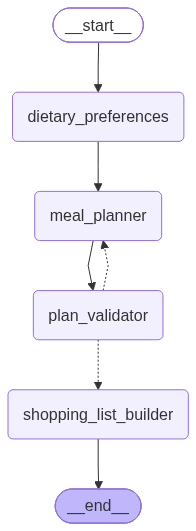

In [93]:
display(Image(data=recipe_graph.get_graph().draw_mermaid_png(), format="png"))

In [94]:
thread1_config = { "configurable": { "thread_id": "thread_4" } }

In [95]:
def execute_workflow(user_request: str):
  #initialize the graph

  # recipe_graph_builder = StateGraph(RecipePlannerState)
  # recipe_graph_builder.add_node("dietary_preferences", parse_dietary_preferences)
  # recipe_graph_builder.add_node("meal_planner", plan_meal)
  # recipe_graph_builder.add_node("plan_validator", validate_meal_plan)
  # recipe_graph_builder.add_node("shopping_list_builder", build_shopping_list)

  # recipe_graph_builder.add_edge(START, "dietary_preferences")
  # recipe_graph_builder.add_edge("dietary_preferences", "meal_planner")
  # recipe_graph_builder.add_edge("meal_planner", "plan_validator")
  # recipe_graph_builder.add_conditional_edges("plan_validator", validate_meal_plan, ["meal_planner", "shopping_list_builder"])
  # recipe_graph_builder.add_edge("shopping_list_builder", END)
  # recipe_graph = recipe_graph_builder.compile(debug=True)

  #begin execution
  recipe_graph.invoke(input={"user_request": user_request}, config=thread1_config)
  #interuption
  #resume
  #final output
  print("execute_workflow")

In [96]:
execute_workflow(user_request="Give me shopping list for vegetarian family of 4, $75/week budget")

[values] {'user_request': 'Give me shopping list for vegetarian family of 4, $75/week budget', 'dietary_preferences': DietaryPreferences(diet_type='vegetarian', allergies=[], allergies_confirmed=False, dislikes=[], servings=4, days=7, calorie_target=None, budget=75.0, cuisine_preferences=[]), 'validation': 'valid', 'meal_plan_draft': [AIMessage(content='I found many repeated recipes that are not fully suited for your vegetarian preference (they include meat). I will pick and adapt or look for proper vegetarian options for your 7-day meal plan.\n\nHere is a 7-day vegetarian meal plan for 4 servings per meal, focusing on variety, quick preparation, and balanced nutrition:\n\nDay 1:\n- Breakfast: Vegetable and Cheese Omelette with Whole Grain Toast\n- Lunch: Quinoa Salad with Roasted Vegetables and Feta Cheese\n- Dinner: Lentil Curry with Brown Rice and Steamed Broccoli\n\nDay 2:\n- Breakfast: Greek Yogurt with Honey, Walnuts, and Fresh Berries\n- Lunch: Caprese Sandwich with Mozzarella, 

/usr/local/lib/python3.13/dist-packages/pydantic/json_schema.py:2463: PydanticJsonSchemaWarning: Default value (FieldInfo(annotation=NoneType, required=False, default=False, description="True only if the user was explicitly asked about allergies (this session or a prior one) and confirmed an answer, including 'none'. False means 'unknown', not 'no allergies'."),) is not JSON serializable; excluding default from JSON schema [non-serializable-default]
  warnings.warn(message, PydanticJsonSchemaWarning)


[updates] {'dietary_preferences': {'dietary_preferences': DietaryPreferences(diet_type='vegetarian', allergies=[], allergies_confirmed=False, dislikes=[], servings=4, days=7, calorie_target=None, budget=75.0, cuisine_preferences=[])}}
[values] {'user_request': 'Give me shopping list for vegetarian family of 4, $75/week budget', 'dietary_preferences': DietaryPreferences(diet_type='vegetarian', allergies=[], allergies_confirmed=False, dislikes=[], servings=4, days=7, calorie_target=None, budget=75.0, cuisine_preferences=[]), 'validation': 'valid', 'meal_plan_draft': [AIMessage(content='I found many repeated recipes that are not fully suited for your vegetarian preference (they include meat). I will pick and adapt or look for proper vegetarian options for your 7-day meal plan.\n\nHere is a 7-day vegetarian meal plan for 4 servings per meal, focusing on variety, quick preparation, and balanced nutrition:\n\nDay 1:\n- Breakfast: Vegetable and Cheese Omelette with Whole Grain Toast\n- Lunch: